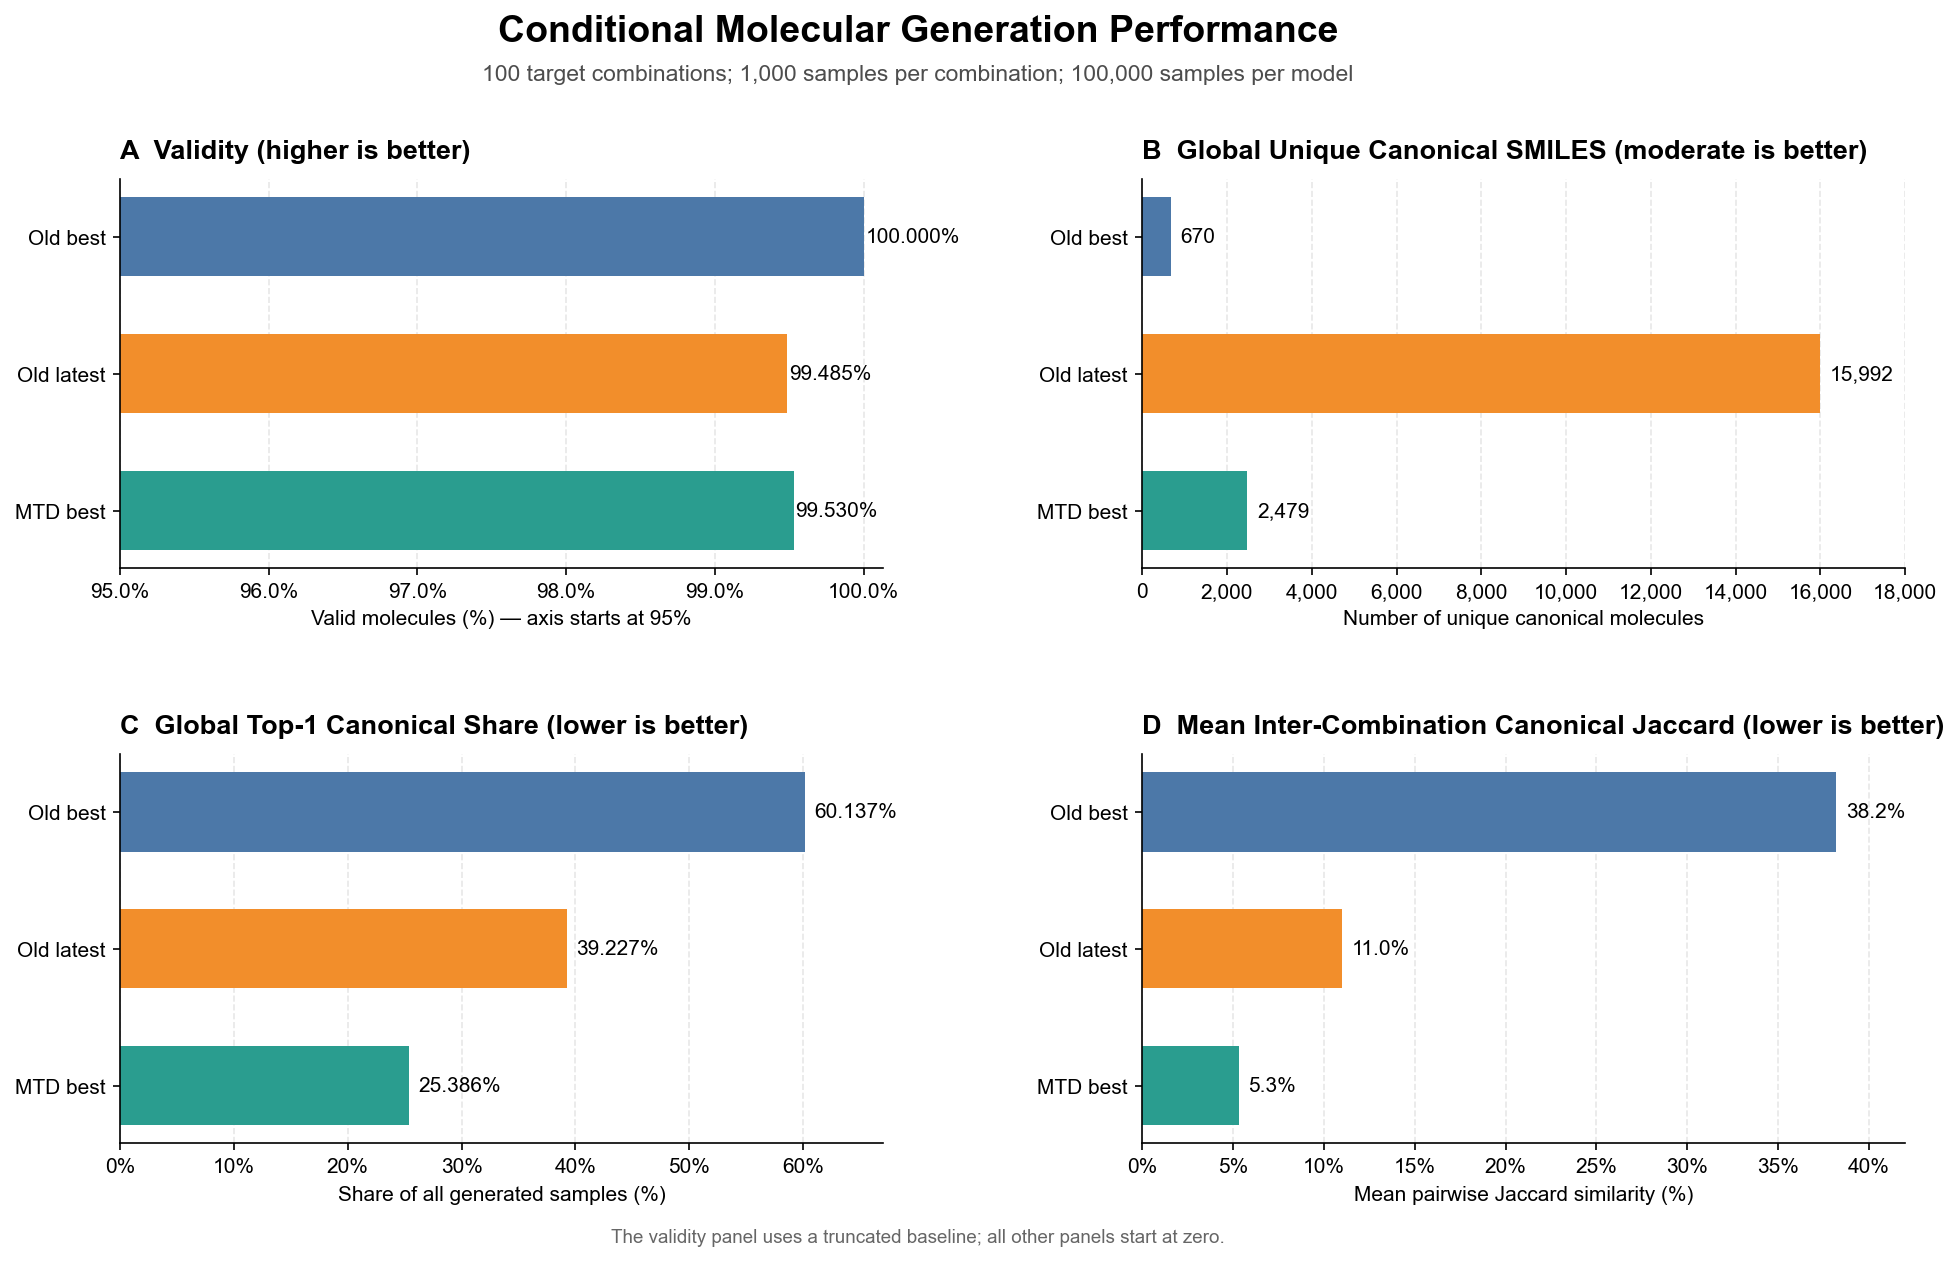

In [3]:
# Four-metric comparison of the 2026-08-16 conditional generation results
# Source: the first table in the 2026-08-16 project record

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Global plotting style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'axes.unicode_minus': False,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

# Model labels and colors remain consistent across all panels
models = ['Old best', 'Old latest', 'MTD best']
colors = ['#4C78A8', '#F28E2B', '#2A9D8F']
y_positions = np.arange(len(models))[::-1]

# Values from the project record
validity = np.array([100.000, 99.485, 99.530])
unique_canonical = np.array([670, 15992, 2479])
global_top1_share = np.array([60.137, 39.227, 25.386])
mean_canonical_jaccard = np.array([38.2, 11.0, 5.3])  # Displayed as percentages

fig, axes = plt.subplots(2, 2, figsize=(14, 8.8))
fig.subplots_adjust(
    left=0.12, right=0.97, bottom=0.11, top=0.84,
    wspace=0.34, hspace=0.48
)

fig.suptitle(
    'Conditional Molecular Generation Performance',
    fontsize=18, fontweight='bold', y=0.965
)
fig.text(
    0.5, 0.915,
    '100 target combinations; 1,000 samples per combination; 100,000 samples per model',
    ha='center', fontsize=11, color='#4D4D4D'
)

def style_axis(ax, title, xlabel, xlim):
    ax.set_title(title, loc='left', fontsize=13, pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_yticks(y_positions, models)
    ax.set_xlim(*xlim)
    ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.30)
    ax.set_axisbelow(True)

# A. Validity: the baseline is explicitly shifted to 95% to reveal small differences
ax = axes[0, 0]
validity_baseline = 95
validity_bars = ax.barh(
    y_positions, validity - validity_baseline, left=validity_baseline,
    height=0.58, color=colors, edgecolor='none'
)
style_axis(
    ax, 'A  Validity (higher is better)',
    'Valid molecules (%) — axis starts at 95%', (95, 100.13)
)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.1f}%'))
for bar, value in zip(validity_bars, validity):
    ax.text(
        value + 0.012, bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}%', va='center', ha='left', fontsize=10
    )

# B. Global canonical diversity
ax = axes[0, 1]
canonical_bars = ax.barh(
    y_positions, unique_canonical, height=0.58,
    color=colors, edgecolor='none'
)
style_axis(
    ax, 'B  Global Unique Canonical SMILES (moderate is better)',
    'Number of unique canonical molecules', (0, 18000)
)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:,.0f}'))
for bar, value in zip(canonical_bars, unique_canonical):
    ax.text(
        value + 230, bar.get_y() + bar.get_height() / 2,
        f'{value:,}', va='center', ha='left', fontsize=10
    )

# C. Global concentration of the most frequent molecule
ax = axes[1, 0]
top1_bars = ax.barh(
    y_positions, global_top1_share, height=0.58,
    color=colors, edgecolor='none'
)
style_axis(
    ax, 'C  Global Top-1 Canonical Share (lower is better)',
    'Share of all generated samples (%)', (0, 67)
)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.0f}%'))
for bar, value in zip(top1_bars, global_top1_share):
    ax.text(
        value + 0.8, bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}%', va='center', ha='left', fontsize=10
    )

# D. Overlap of canonical molecule sets across target combinations
ax = axes[1, 1]
jaccard_bars = ax.barh(
    y_positions, mean_canonical_jaccard, height=0.58,
    color=colors, edgecolor='none'
)
style_axis(
    ax, 'D  Mean Inter-Combination Canonical Jaccard (lower is better)',
    'Mean pairwise Jaccard similarity (%)', (0, 42)
)
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.0f}%'))
for bar, value in zip(jaccard_bars, mean_canonical_jaccard):
    ax.text(
        value + 0.55, bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%', va='center', ha='left', fontsize=10
    )

fig.text(
    0.5, 0.035,
    'The validity panel uses a truncated baseline; all other panels start at zero.',
    ha='center', fontsize=9, color='#666666'
)

# Uncomment the next line to save a publication-quality image.
# fig.savefig('four_metric_checkpoint_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


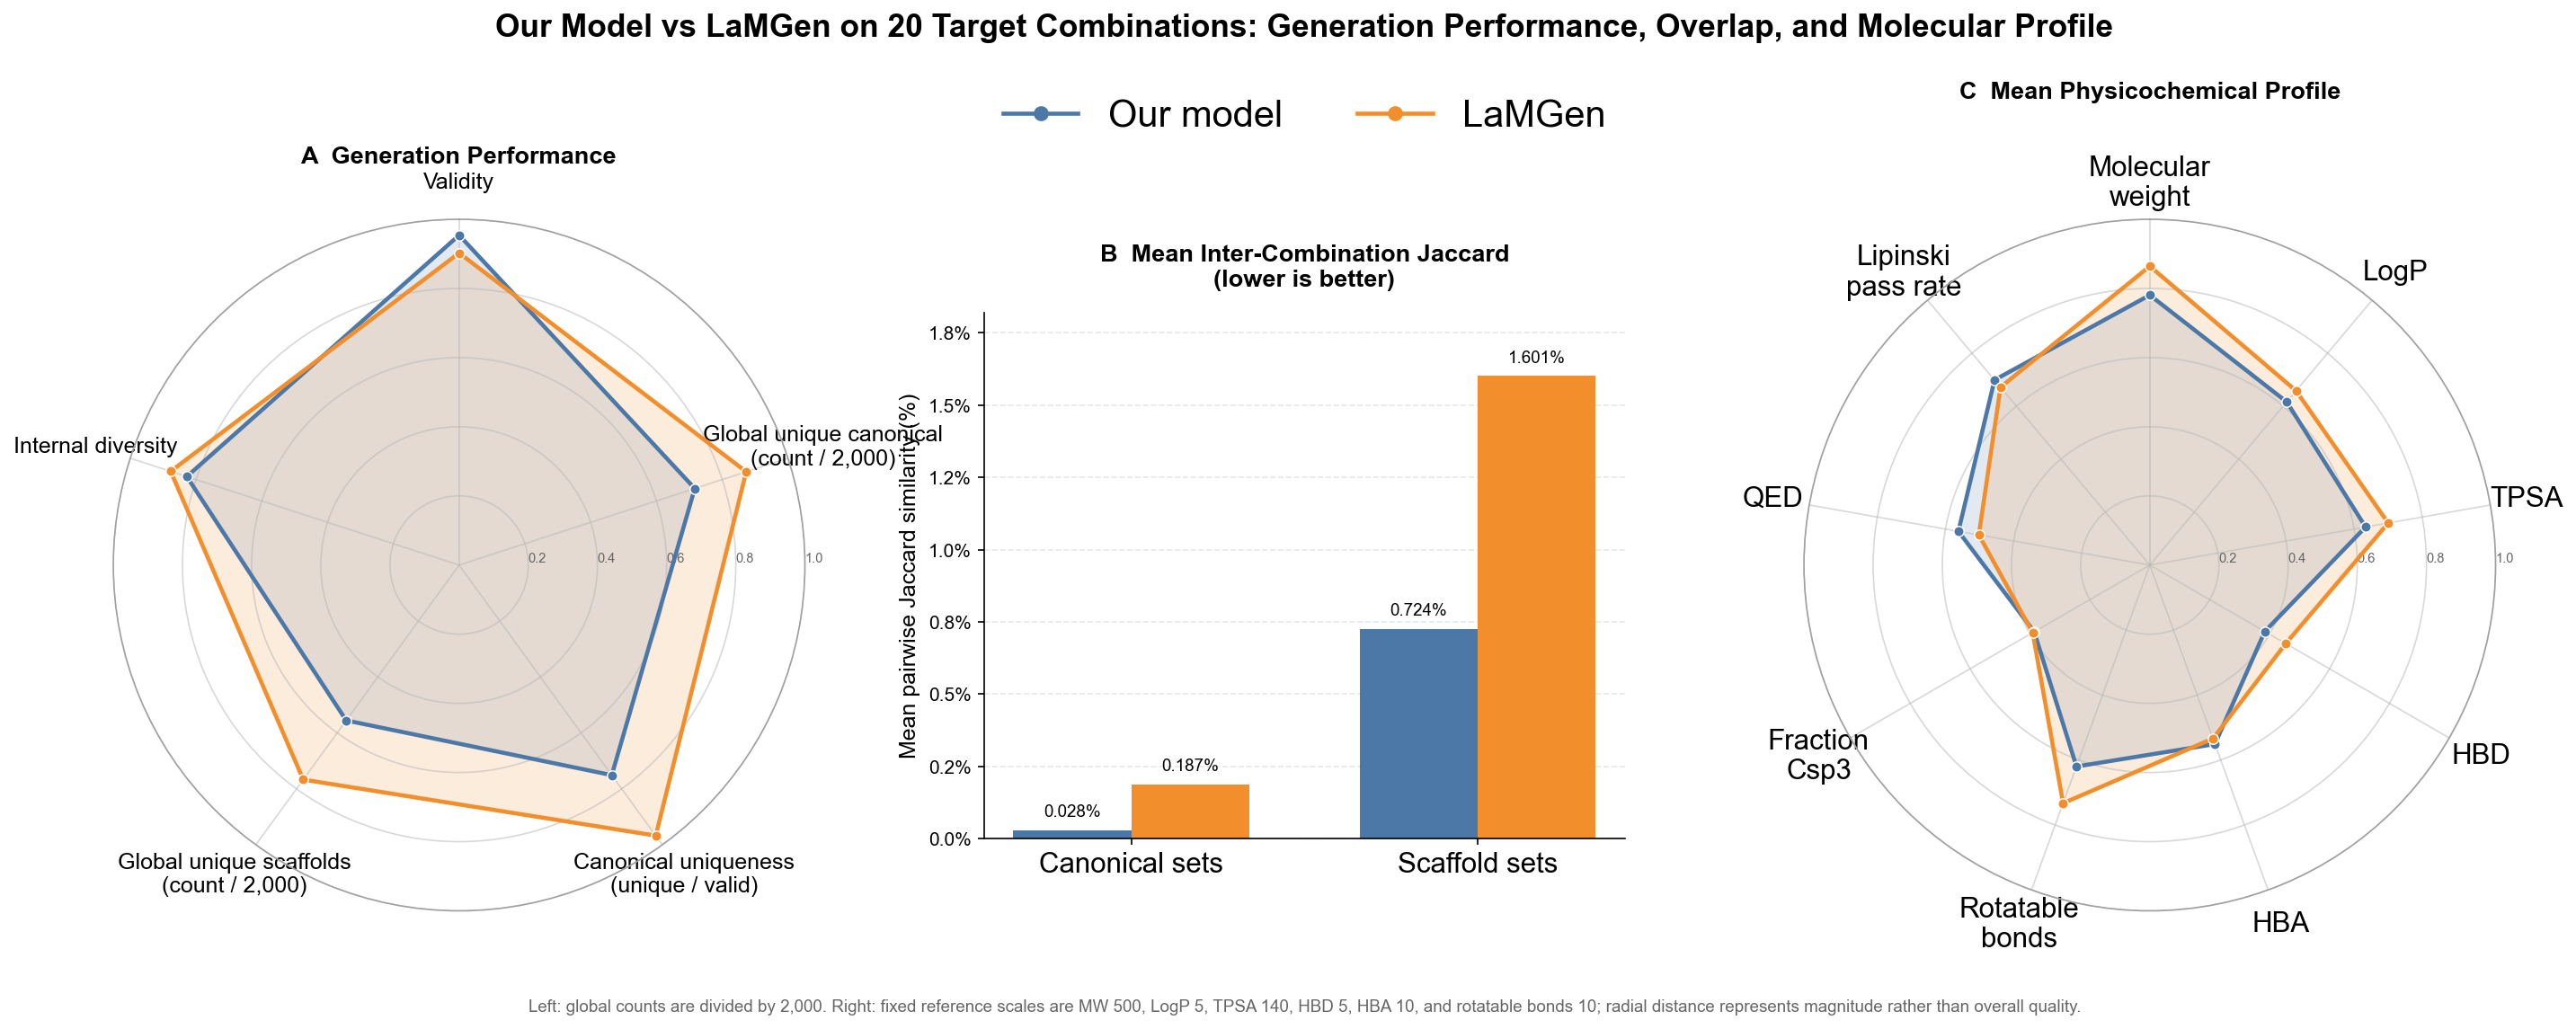

In [1]:
# Three-panel comparison of the in-house model and LaMGen
# The two radar axes use identical dimensions and symmetric positions.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'axes.unicode_minus': False,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

model_names = ['Our model', 'LaMGen']
model_colors = ['#4C78A8', '#F28E2B']
total_samples = 2000

def closed(values):
    values = np.asarray(values, dtype=float)
    return np.concatenate([values, values[:1]])

def draw_radar(ax, labels, model_values, title, label_size=9):
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    closed_angles = closed(angles)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=label_size)
    ax.tick_params(axis='x', pad=9)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7, color='#666666')
    ax.set_rlabel_position(90)
    ax.grid(color='#B8B8B8', linewidth=0.8, alpha=0.55)
    ax.spines['polar'].set_color('#A0A0A0')
    ax.set_title(title, fontsize=13, pad=30)

    for values, color in zip(model_values, model_colors):
        ax.plot(closed_angles, closed(values), color=color, linewidth=2.2)
        ax.fill(closed_angles, closed(values), color=color, alpha=0.16)
        ax.scatter(angles, values, color=color, s=30, edgecolor='white', linewidth=0.7, zorder=3)

# Panel A: generation performance
performance_labels = [
    'Validity',
    'Global unique canonical\n(count / 2,000)',
    'Canonical uniqueness\n(unique / valid)',
    'Global unique scaffolds\n(count / 2,000)',
    'Internal diversity',
]
inhouse_performance = np.array([
    0.9540,
    1433 / total_samples,
    0.7510,
    1111 / total_samples,
    0.828,
])
lamgen_performance = np.array([
    0.9025,
    1746 / total_samples,
    0.9673,
    1534 / total_samples,
    0.877,
])

# Panel B: mean pairwise overlap across target combinations
overlap_categories = ['Canonical sets', 'Scaffold sets']
inhouse_overlap_pct = np.array([0.00028, 0.00724]) * 100
lamgen_overlap_pct = np.array([0.00187, 0.01601]) * 100

# Panel C: mean physicochemical profile
# Fixed reference denominators place heterogeneous properties on a 0-1 scale.
property_labels = [
    'Molecular\nweight', 'LogP', 'TPSA', 'HBD', 'HBA',
    'Rotatable\nbonds', 'Fraction\nCsp3', 'QED', 'Lipinski\npass rate'
]
property_reference = np.array([500.0, 5.0, 140.0, 5.0, 10.0, 10.0, 1.0, 1.0, 1.0])
inhouse_property_raw = np.array([
    390.38, 3.08, 88.71, 1.92, 5.51, 6.20, 0.386, 0.562, 0.6986
])
lamgen_property_raw = np.array([
    432.13, 3.29, 98.00, 2.27, 5.34, 7.33, 0.391, 0.502, 0.6715
])
inhouse_property = inhouse_property_raw / property_reference
lamgen_property = lamgen_property_raw / property_reference

# Manual axis rectangles guarantee equal radar sizes and mirror symmetry.
figure = plt.figure(figsize=(19, 7.8), dpi=150, facecolor='white')
radar_width = 0.27
radar_height = 0.66
radar_bottom = 0.13
left_radar_x = 0.035
right_radar_x = 1.0 - left_radar_x - radar_width

ax_performance = figure.add_axes(
    [left_radar_x, radar_bottom, radar_width, radar_height], projection='polar'
)
ax_overlap = figure.add_axes([0.375, 0.20, 0.25, 0.50])
ax_properties = figure.add_axes(
    [right_radar_x, radar_bottom, radar_width, radar_height], projection='polar'
)

draw_radar(
    ax_performance, performance_labels,
    [inhouse_performance, lamgen_performance],
    'A  Generation Performance', label_size=12
)

# Draw the grouped bar chart in the central panel.
category_positions = np.arange(len(overlap_categories))
bar_width = 0.34
inhouse_bars = ax_overlap.bar(
    category_positions - bar_width / 2, inhouse_overlap_pct,
    width=bar_width, color=model_colors[0], label=model_names[0]
)
lamgen_bars = ax_overlap.bar(
    category_positions + bar_width / 2, lamgen_overlap_pct,
    width=bar_width, color=model_colors[1], label=model_names[1]
)
ax_overlap.set_title('B  Mean Inter-Combination Jaccard\n(lower is better)', fontsize=13, pad=14)
ax_overlap.set_xticks(category_positions, overlap_categories, fontsize=15)
ax_overlap.set_ylabel('Mean pairwise Jaccard similarity (%)', fontsize=12)
ax_overlap.set_ylim(0, 1.82)
ax_overlap.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.1f}%'))
ax_overlap.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.30)
ax_overlap.set_axisbelow(True)
for bars in [inhouse_bars, lamgen_bars]:
    for bar in bars:
        value = bar.get_height()
        ax_overlap.text(
            bar.get_x() + bar.get_width() / 2, value + 0.035,
            f'{value:.3f}%', ha='center', va='bottom', fontsize=9
        )

draw_radar(
    ax_properties, property_labels,
    [inhouse_property, lamgen_property],
    'C  Mean Physicochemical Profile', label_size=15
)

figure.suptitle(
    'Our Model vs LaMGen on 20 Target Combinations: Generation Performance, Overlap, and Molecular Profile',
    fontsize=17, fontweight='bold', y=0.985
)
legend_handles = [
    Line2D([0], [0], color=color, marker='o', linewidth=2.2, markersize=7, label=name)
    for name, color in zip(model_names, model_colors)
]
figure.legend(
    handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.935),
    ncol=2, frameon=False, fontsize=20
)
figure.text(
    0.5, 0.035,
    'Left: global counts are divided by 2,000. Right: fixed reference scales are '
    'MW 500, LogP 5, TPSA 140, HBD 5, HBA 10, and rotatable bonds 10; '
    'radial distance represents magnitude rather than overall quality.',
    ha='center', fontsize=9, color='#666666'
)

# Uncomment the next line to save the complete three-panel figure.
# figure.savefig('lamgen_three_panel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


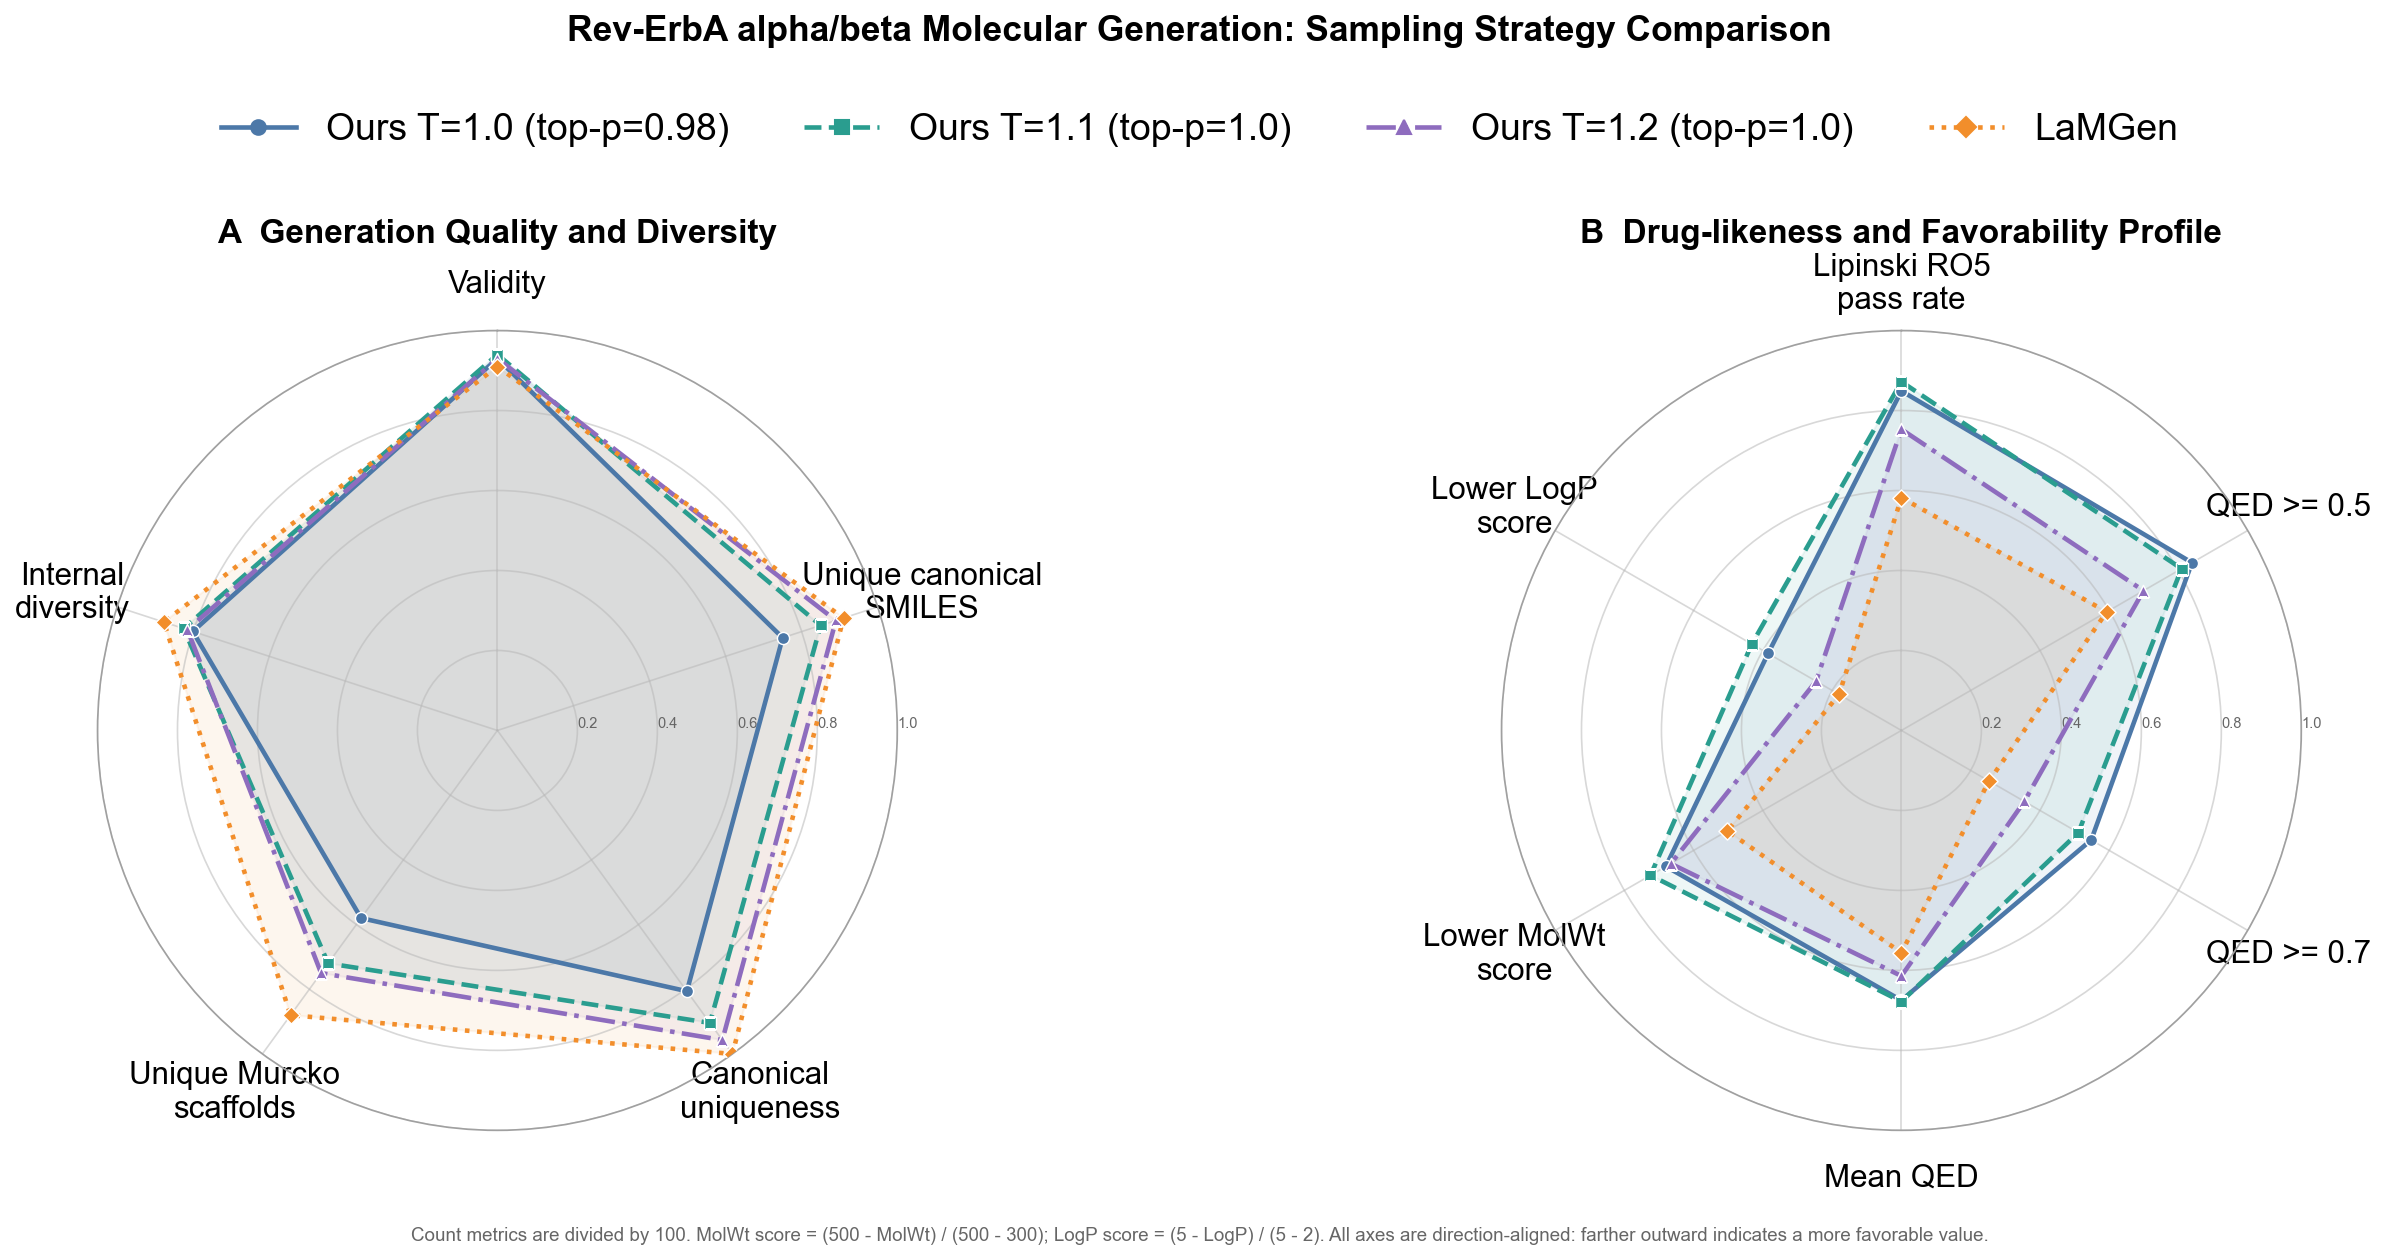

In [4]:
# Two-radar comparison of Rev-ErbA alpha/beta generation results
# Source: the first table in the 2026-08-23 project record

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'axes.unicode_minus': False,
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
})

model_names = [
    'Ours T=1.0 (top-p=0.98)',
    'Ours T=1.1 (top-p=1.0)',
    'Ours T=1.2 (top-p=1.0)',
    'LaMGen',
]
model_colors = ['#4C78A8', '#2A9D8F', '#8E6CBE', '#F28E2B']
line_styles = ['-', '--', '-.', ':']
marker_styles = ['o', 's', '^', 'D']
total_samples = 100

def close_polygon(values):
    values = np.asarray(values, dtype=float)
    return np.concatenate([values, values[:1]])

def draw_radar(ax, labels, model_values, title, label_size=10):
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    closed_angles = close_polygon(angles)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=label_size)
    ax.tick_params(axis='x', pad=12)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(
        ['0.2', '0.4', '0.6', '0.8', '1.0'],
        fontsize=7, color='#666666'
    )
    ax.set_rlabel_position(90)
    ax.grid(color='#B8B8B8', linewidth=0.8, alpha=0.55)
    ax.spines['polar'].set_color('#A0A0A0')
    ax.set_title(title, fontsize=16, pad=4, y=1.10)

    for values, color, line_style, marker in zip(
        model_values, model_colors, line_styles, marker_styles
    ):
        values = np.asarray(values, dtype=float)
        ax.plot(
            closed_angles, close_polygon(values),
            color=color, linewidth=2.2, linestyle=line_style
        )
        ax.fill(closed_angles, close_polygon(values), color=color, alpha=0.08)
        ax.scatter(
            angles, values, color=color, marker=marker, s=34,
            edgecolor='white', linewidth=0.7, zorder=3
        )

# Panel A: validity, uniqueness, scaffold coverage, and internal diversity.
# Count metrics are divided by the common sample size of 100.
generation_labels = [
    'Validity',
    'Unique canonical\nSMILES',
    'Canonical\nuniqueness',
    'Unique Murcko\nscaffolds',
    'Internal\ndiversity',
]
generation_raw = np.array([
    [0.930, 75, 0.806, 58, 0.801],
    [0.940, 85, 0.904, 72, 0.825],
    [0.930, 89, 0.957, 75, 0.815],
    [0.910, 91, 1.000, 88, 0.877],
])
generation_values = generation_raw.copy()
generation_values[:, [1, 3]] /= total_samples

# Panel B: direction-aligned drug-likeness and physicochemical favorability.
# MolWt and LogP use fixed-range reverse scores so lower values plot outward.
drug_likeness_labels = [
    'Lipinski RO5\npass rate',
    'QED >= 0.5',
    'QED >= 0.7',
    'Mean QED',
    'Lower MolWt\nscore',
    'Lower LogP\nscore',
]
drug_likeness_raw = np.array([
    [0.849, 0.839, 0.548, 0.675, 363.97, 3.845],
    [0.872, 0.809, 0.511, 0.678, 355.09, 3.704],
    [0.753, 0.699, 0.355, 0.614, 366.78, 4.261],
    [0.582, 0.593, 0.253, 0.556, 399.51, 4.460],
])
drug_likeness_values = drug_likeness_raw.copy()
molwt_lower_reference, molwt_upper_reference = 300.0, 500.0
logp_lower_reference, logp_upper_reference = 2.0, 5.0
drug_likeness_values[:, 4] = np.clip(
    (molwt_upper_reference - drug_likeness_raw[:, 4])
    / (molwt_upper_reference - molwt_lower_reference),
    0.0, 1.0
)
drug_likeness_values[:, 5] = np.clip(
    (logp_upper_reference - drug_likeness_raw[:, 5])
    / (logp_upper_reference - logp_lower_reference),
    0.0, 1.0
)

assert np.all((generation_values >= 0) & (generation_values <= 1))
assert np.all((drug_likeness_values >= 0) & (drug_likeness_values <= 1))

# Manual axis placement keeps both radar charts equal in size and symmetric.
figure = plt.figure(figsize=(18, 8.6), dpi=150, facecolor='white')
radar_width = 0.37
radar_height = 0.62
radar_bottom = 0.12
left_radar_x = 0.055
right_radar_x = 1.0 - left_radar_x - radar_width

ax_generation = figure.add_axes(
    [left_radar_x, radar_bottom, radar_width, radar_height], projection='polar'
)
ax_drug_likeness = figure.add_axes(
    [right_radar_x, radar_bottom, radar_width, radar_height], projection='polar'
)

draw_radar(
    ax_generation, generation_labels, generation_values,
    'A  Generation Quality and Diversity', label_size=15
)
draw_radar(
    ax_drug_likeness, drug_likeness_labels, drug_likeness_values,
    'B  Drug-likeness and Favorability Profile', label_size=15
)

figure.suptitle(
    'Rev-ErbA alpha/beta Molecular Generation: Sampling Strategy Comparison',
    fontsize=17, fontweight='bold', y=0.985
)
legend_handles = [
    Line2D(
        [0], [0], color=color, marker=marker, linestyle=line_style,
        linewidth=2.2, markersize=7, label=name
    )
    for name, color, line_style, marker in zip(
        model_names, model_colors, line_styles, marker_styles
    )
]
figure.legend(
    handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.935),
    ncol=4, frameon=False, fontsize=18
)
figure.text(
    0.5, 0.035,
    'Count metrics are divided by 100. MolWt score = (500 - MolWt) / (500 - 300); '
    'LogP score = (5 - LogP) / (5 - 2). All axes are direction-aligned: '
    'farther outward indicates a more favorable value.',
    ha='center', fontsize=9, color='#666666'
)

# Uncomment the next line to save a publication-quality image.
# figure.savefig('rev_erba_sampling_radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
